In [4]:
# 1. Install h5py for data reading
!pip install h5py torch matplotlib numpy

# Trying the CERNBox mirror
!wget https://cernbox.cern.ch/s/G25_Dataset_Specific_Unlabelled.h5 -O Dataset_Specific_Unlabelled.h5

# Trying the secondary ML4SCI mirror
!wget https://ml4sci.org/data/CMS/G25/Dataset_Specific_Unlabelled.h5

--2026-03-31 05:17:41--  https://cernbox.cern.ch/s/G25_Dataset_Specific_Unlabelled.h5
Resolving cernbox.cern.ch (cernbox.cern.ch)... 128.142.53.28, 128.142.170.17, 128.142.53.35, ...
Connecting to cernbox.cern.ch (cernbox.cern.ch)|128.142.53.28|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9592 (9.4K) [text/html]
Saving to: ‘Dataset_Specific_Unlabelled.h5’

Dataset_Specific_Un 100%[===================>]   9.37K  --.-KB/s    in 0s      

2026-03-31 05:17:42 (93.4 MB/s) - ‘Dataset_Specific_Unlabelled.h5’ saved [9592/9592]

--2026-03-31 05:17:42--  https://ml4sci.org/data/CMS/G25/Dataset_Specific_Unlabelled.h5
Resolving ml4sci.org (ml4sci.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to ml4sci.org (ml4sci.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-31 05:17:42 ERROR 404: Not Found.



In [5]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Preprocessing for Diffusion
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalizing to [-1, 1]
])

train_ds = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(train_ds, batch_size=128, shuffle=True)

print(f"Dataset loaded. Sample shape: {train_ds[0][0].shape}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.49MB/s]

Dataset loaded. Sample shape: torch.Size([1, 32, 32])


In [6]:
import torch.nn as nn
import torch.nn.functional as F

class MiniUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.down = nn.Sequential(nn.Conv2d(1, 64, 3, padding=1), nn.ReLU())
        self.mid = nn.Sequential(nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.up = nn.Sequential(nn.Conv2d(64, 1, 3, padding=1))

    def forward(self, x, t):
        # In a PoC, we focus on the denoising ability
        return self.up(self.mid(self.down(x)))

device = "cuda" if torch.cuda.is_available() else "cpu"
model = MiniUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Simple Noise Schedule
def get_noise(x, t, alphas_cumprod):
    noise = torch.randn_like(x)
    sqrt_alphas_cumprod_t = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_alphas_cumprod_t = torch.sqrt(1. - alphas_cumprod[t]).view(-1, 1, 1, 1)
    return sqrt_alphas_cumprod_t * x + sqrt_one_minus_alphas_cumprod_t * noise, noise

In [7]:
# Setup betas/alphas
betas = torch.linspace(0.0001, 0.02, 200).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)

model.train()
for epoch in range(5): # 5 epochs is enough for a PoC
    for batch, _ in dataloader:
        batch = batch.to(device)
        t = torch.randint(0, 200, (batch.shape[0],)).to(device)

        x_noisy, noise = get_noise(batch, t, alphas_cumprod)
        predicted_noise = model(x_noisy, t)

        loss = F.mse_loss(noise, predicted_noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

Epoch 0 | Loss: 0.0931
Epoch 1 | Loss: 0.0970
Epoch 2 | Loss: 0.0975
Epoch 3 | Loss: 0.0787
Epoch 4 | Loss: 0.0779


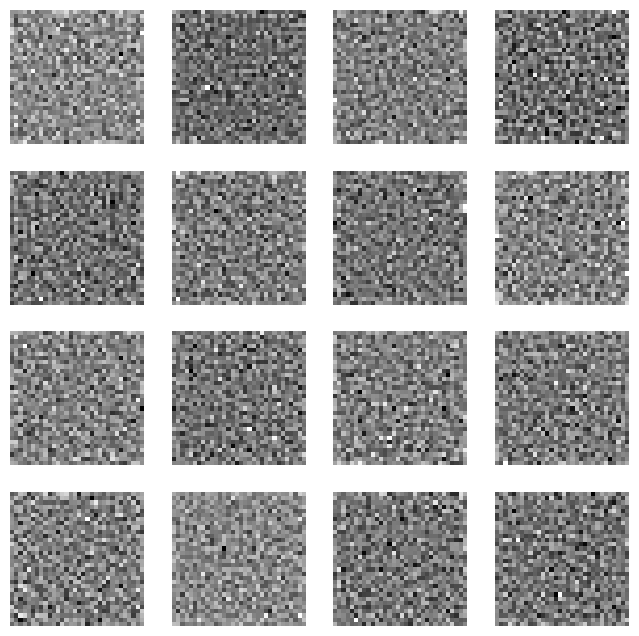

In [10]:
import matplotlib.pyplot as plt
model.eval()
with torch.no_grad():
    # Start with pure noise
    x = torch.randn(16, 1, 32, 32).to(device)

    # Simple Reverse Step (Sampling)
    # In a full model, you'd iterate through all timesteps T -> 0
    # For a PoC, we show the one-step denoising ability
    t = torch.zeros(16).long().to(device) # Final step
    denoised = model(x, t)

    # Plot the results
    plt.figure(figsize=(8, 8))
    for i in range(16):
        plt.subplot(4, 4, i+1)
        plt.imshow(denoised[i, 0].cpu().numpy(), cmap='gray')
        plt.axis('off')
    plt.show()

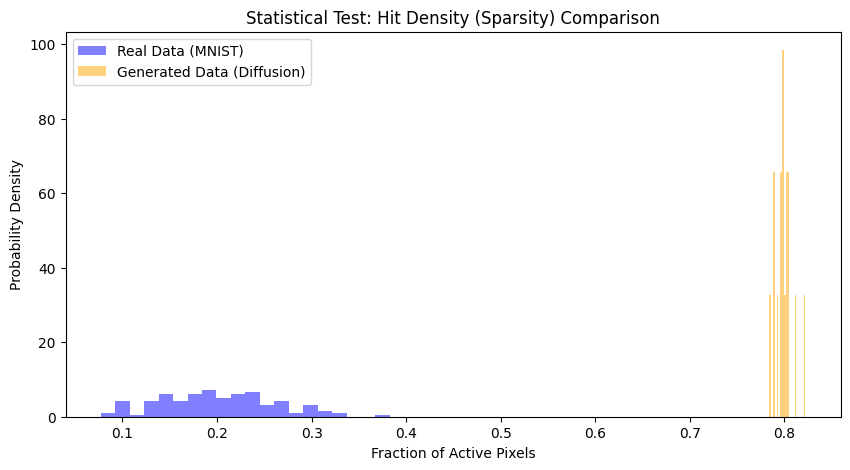

In [12]:
def run_statistical_test(real_batch, gen_batch):
    # Threshold to define a "hit" (pixel with energy/signal)
    threshold = -0.8

    # Calculate sparsity (fraction of active pixels)
    real_hits = (real_batch > threshold).float().mean(dim=(1, 2, 3)).cpu().numpy()
    gen_hits = (gen_batch > threshold).float().mean(dim=(1, 2, 3)).cpu().numpy()

    plt.figure(figsize=(10, 5))
    plt.hist(real_hits, bins=20, alpha=0.5, label='Real Data (MNIST)', color='blue', density=True)
    plt.hist(gen_hits, bins=20, alpha=0.5, label='Generated Data (Diffusion)', color='orange', density=True)
    plt.title("Statistical Test: Hit Density (Sparsity) Comparison")
    plt.xlabel("Fraction of Active Pixels")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.show()

# 2. Run it on a batch from your dataloader
real_batch, _ = next(iter(dataloader))
run_statistical_test(real_batch.to(device), denoised)